In [70]:
from scipy.io.wavfile import read, write
from IPython.display import Audio

#path = "COMBINED.wav"
path = "00f0204f_nohash_1.wav"
Fs, data = read(path)  #'00f0204f_nohash_0.wav')
#data = data[:11000]
print(data)
Audio(data, rate=Fs)

[-8 -4 -7 ...  7  8 15]


one wav file has ~4431 indices or less

In [15]:
data.max()

25579

In [4]:
from pydub import AudioSegment
from pydub.playback import play

sound = AudioSegment.from_file("mysound.wav", format="wav")
play(sound)

ImportError: No module named pydub

In [68]:
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
#import csv
import os.path
from os import path
from preprocess import preprocessing
%matplotlib inline

ImportError: No module named preprocess

from scikits.audiolab import wavread

data1, fs1, enc1 = wavread("file1.wav")
data2, fs2, enc2 = wavread("file2.wav")

assert fs1 == fs2
assert enc1 == enc2
result = 0.5 * data1 + 0.5 * data2

from pydub import AudioSegment #use b2h

sound1 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\0a196374_nohash_0.wav")
sound2 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\0a196374_nohash_1.wav")
sound3 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\0a196374_nohash_2.wav")
sound4 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\0a2b400e_nohash_0.wav")
sound5 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\0a2b400e_nohash_1.wav")
sound6 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\0a2b400e_nohash_2.wav")
sound7 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\0a2b400e_nohash_3.wav")
sound8 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\0a7c2a8d_nohash_0.wav")
sound9 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\0a7c2a8d_nohash_1.wav")
sound10 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\0a7c2a8d_nohash_2.wav")
sound11 = AudioSegment.from_file("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\00f0204f_nohash_0.wav")


combined = sound1+sound2+sound3+sound4+sound5+sound6+sound7+sound8+sound9+sound10+sound11
#sound1.overlay(sound2)

combined.export("C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\combined.wav", format='wav')

In [61]:
prefix = 'C:\Users\micha\CODE\OB_EPL (1)\OB_EPL\''
suffix = ".wav"
sounds = ["0a196374_nohash_0","0a196374_nohash_1","0a196374_nohash_2","0a2b400e_nohash_0","0a2b400e_nohash_1","0a2b400e_nohash_2","0a2b400e_nohash_3","0a7c2a8d_nohash_0","0a7c2a8d_nohash_1","0a7c2a8d_nohash_2","00f0204f_nohash_0"]

In [59]:
cfmin, cfmax, cfN = 50*b2.Hz, 3*b2.kHz, 100
# 72 chemosensors, but changing to 100 leads to finer frequencies and the network still works
# 50 to 3000 Hz because normal human speech is within these frequencies
cf = b2h.erbspace(cfmin, cfmax, cfN)
sound = b2h.loadsound('COMBINED.wav')
#sound.save('COMBINED.wav')
sound = sound[:8500]
gfb = b2h.Gammatone(sound, cf)
'''
ihc = b2h.FunctionFilterbank(gfb, lambda x: 3*clip(x, 0, Inf)**(1.0/3.0))
# Leaky integrate-and-fire model with noise and refractoriness
eqs = '''
#dv/dt = (I-v)/(1*ms)+0.2*xi*(2/(1*ms))**.5 : 1 (unless refractory)
#I : 1
'''
G = b2h.FilterbankGroup(ihc, 'I', eqs, reset='v=0', threshold='v>1', refractory=5*b2.ms)
'''

creating c:\users\micha\appdata\local\temp\weave-micha-wwxydo\python27_intermediate\compiler_e3b0c44298fc1c149afbf4c8996fb924
Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


"\nG = b2h.FilterbankGroup(ihc, 'I', eqs, reset='v=0', threshold='v>1', refractory=5*b2.ms)\n"

Text(0.5,0,'Time (index)')

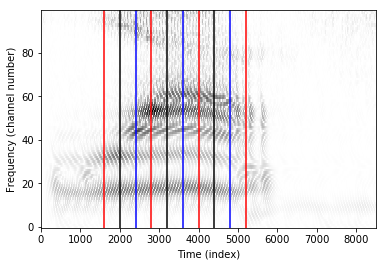

In [60]:
X = np.abs(gfb.process().T)
#X[30:,:]*=3
X = np.log(X+.01)
X += X.min()
plt.imshow(X,aspect='auto', origin='lower left')

xcoords = np.array([200,250,300,350,400,450,500,550,600,650])*8
testDataName = "testOdorList4.txt"

 
colors = ['r','k','b','r','k','b','r','k','b','r']*10
for xc,c in zip(xcoords,colors):                    #changed xcoords2 to xcoords
    plt.axvline(x=xc, label='line at x = {}'.format(xc), c=c)



#locs, labels = yticks()
#xticks()
plt.set_cmap('gray_r')
plt.ylabel('Frequency (channel number)')
plt.xlabel('Time (index)')

take first 5 and put in long vector
convert it to a vector for the network (trainingOdor)
if it doesn't work with 100, lower spectral composition

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


testOdorList4.txt exists


Text(0.5,0,'Time (index)')

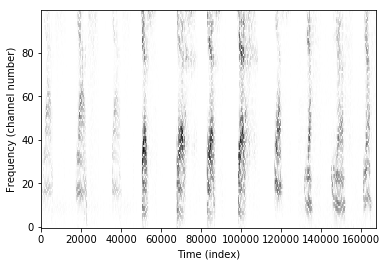

In [56]:
cfmin, cfmax, cfN = 50*b2.Hz, 3*b2.kHz, 100
# 72 chemosensors, but changing to 100 leads to finer frequencies and the network still works
# 50 to 3000 Hz because normal human speech is within these frequencies
cf = b2h.erbspace(cfmin, cfmax, cfN)
sound = b2h.loadsound('COMBINED.wav')
sound.save('COMBINED.wav')
#sound = sound[:]
gfb = b2h.Gammatone(sound, cf)
ihc = b2h.FunctionFilterbank(gfb, lambda x: 3*clip(x, 0, Inf)**(1.0/3.0))
# Leaky integrate-and-fire model with noise and refractoriness
eqs = '''
dv/dt = (I-v)/(1*ms)+0.2*xi*(2/(1*ms))**.5 : 1 (unless refractory)
I : 1
'''
G = b2h.FilterbankGroup(ihc, 'I', eqs, reset='v=0', threshold='v>1', refractory=5*b2.ms)
X = np.abs(gfb.process().T)
#X[30:,:]*=3
X = np.log(X+.01)
X += X.min()
plt.imshow(X,aspect='auto', origin='lower left')


testDataName = "testOdorList4.txt"

# check if testDataName exists. If it exists, load it. If it doesn't exist, continue with creating the file as below
if path.exists(testDataName):
    xcoords2 = np.loadtxt(testDataName)
    print(testDataName+" exists")
colors = ['r','k','b','r','k','b','r','k','b','r']*10
'''
for xc,c in zip(xcoords2,colors):                    #changed xcoords2 to xcoords
    plt.axvline(x=xc, label='line at x = {}'.format(xc), c=c)
'''


#locs, labels = yticks()
#xticks()
plt.set_cmap('gray_r')
plt.ylabel('Frequency (channel number)')
plt.xlabel('Time (index)')

In [57]:
scale = 10
#scale = 33.6
trainingOdors = X[:,xcoords[:]].T/X.max()*scale
trainingOdors = trainingOdors.astype(np.int64)

testOdors = X[:,xcoords2[:]].T/X.max()*scale
testOdors = testOdors.astype(np.int64)

IndexError: arrays used as indices must be of integer (or boolean) type

In [72]:
X.shape

(100L, 8500L)

In [73]:
X

array([[-9.21034037, -9.21034037, -9.21034037, ..., -9.19961723,
        -9.20005308, -9.20049593],
       [-9.21034037, -9.21034037, -9.21034037, ..., -9.20540517,
        -9.20471996, -9.2040389 ],
       [-9.21034037, -9.21034037, -9.21034037, ..., -9.18899118,
        -9.18850231, -9.18802916],
       ...,
       [-9.21034037, -9.21034037, -9.21034037, ..., -9.16992124,
        -9.18450757, -9.15614627],
       [-9.21034037, -9.21034037, -9.21034037, ..., -9.18118208,
        -9.15774503, -9.19708575],
       [-9.21034037, -9.21034037, -9.21034037, ..., -9.16062722,
        -9.20380754, -9.16894922]])